# DeepVO Project Demo

This notebook summarizes the DeepVO portion of the monocular localization/mapping semester project. It is designed as a clean report companion: it documents the workflow, records the exact project paths, and displays the main trajectory outputs.

Final written summary: `reports/drafts/deepvo_summary.md`.

## 1. Introduction to DeepVO

DeepVO is a deep learning approach for monocular visual odometry. Instead of hand-designing feature matching and geometric pose estimation, DeepVO learns to predict camera motion from pairs or short sequences of monocular images.

In this project, DeepVO is used to estimate relative camera motion from image sequences. The predicted relative motions are accumulated into a trajectory for visualization.

## 2. Project Context

This project studies monocular localization and mapping using a MacBook M4. The first implementation path uses DeepVO for visual odometry. Later work can add ORB-SLAM3 for a more classical SLAM pipeline.

Important project folders:

- `src/models/deepvo/` contains the cloned and patched DeepVO repository.
- `data/custom/raw_videos/` contains custom input videos.
- `data/custom/extracted_frames/` contains extracted frame sequences.
- `data/benchmark/kitti/` contains KITTI odometry data.
- `outputs/trajectories/deepvo/` contains DeepVO trajectory CSV outputs.
- `outputs/plots/deepvo/` contains trajectory plots for report use.

In [1]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PROJECT_ROOT

PosixPath('/Users/ray/monocular-slam-project/monocular_slam_project')

## 3. Environment and Setup Notes for MacBook M4

The DeepVO code was patched to avoid hardcoded CUDA calls. The model now selects Apple Silicon MPS when available and falls back to CPU otherwise.

Setup commands from the project root:

```bash
python3 -m venv .venv
source .venv/bin/activate
python -m pip install --upgrade pip
python -m pip install -r requirements.txt
```

For Apple Silicon runs, this environment variable can help PyTorch fall back to CPU for unsupported MPS operations:

```bash
PYTORCH_ENABLE_MPS_FALLBACK=1
```

In [2]:
try:
    import torch
    print("PyTorch:", torch.__version__)
    print("MPS available:", hasattr(torch.backends, "mps") and torch.backends.mps.is_available())
except ImportError:
    print("PyTorch is not installed in this notebook environment yet.")

PyTorch: 2.11.0
MPS available: True


## 4. Custom Video Preprocessing Summary

The custom videos were converted into frame folders using OpenCV.

Input videos:

- `data/custom/raw_videos/indoor_loop.mov`
- `data/custom/raw_videos/outdoor_loop.mov`

Extracted frames:

- `data/custom/extracted_frames/indoor_loop/`
- `data/custom/extracted_frames/outdoor_loop/`

Script:

- `scripts/preprocessing/extract_frames.py`

In [3]:
custom_frame_dirs = {
    "indoor_loop": PROJECT_ROOT / "data/custom/extracted_frames/indoor_loop",
    "outdoor_loop": PROJECT_ROOT / "data/custom/extracted_frames/outdoor_loop",
}

for name, folder in custom_frame_dirs.items():
    frame_count = len(list(folder.glob("frame_*.png"))) if folder.exists() else 0
    print(f"{name}: {frame_count} frames at {folder.relative_to(PROJECT_ROOT)}")

indoor_loop: 2033 frames at data/custom/extracted_frames/indoor_loop
outdoor_loop: 3748 frames at data/custom/extracted_frames/outdoor_loop


## 5. Model Training Summary on KITTI

The DeepVO model was trained on KITTI odometry data stored under:

- `data/benchmark/kitti/`

This dataset uses grayscale camera folders, so DeepVO was patched to read `image_0` by default. The trained checkpoint used for the demo is:

- `outputs/checkpoints/deepvo_kitti/checkpoint_1.pth`

Training command used for the first checkpoint:

```bash
cd /Users/ray/monocular-slam-project/monocular_slam_project/src/models/deepvo
PYTORCH_ENABLE_MPS_FALLBACK=1 python main.py \
  --mode train \
  --datapath ../../../data/benchmark/kitti \
  --checkpoint_path ../../../outputs/checkpoints/deepvo_kitti \
  --image_folder image_0 \
  --bsize 1 \
  --trajectory_length 10 \
  --train_iter 1
```

In [4]:
checkpoint = PROJECT_ROOT / "outputs/checkpoints/deepvo_kitti/checkpoint_1.pth"
print("Checkpoint exists:", checkpoint.exists())
if checkpoint.exists():
    print("Checkpoint size MB:", round(checkpoint.stat().st_size / (1024 * 1024), 2))

Checkpoint exists: True
Checkpoint size MB: 243.72


## 6. Inference on Custom Datasets

Custom inference uses frame folders as input. Two categories are saved for comparison:

- Random-weight custom outputs: `outputs/trajectories/deepvo/custom_random/`
- Trained-checkpoint custom outputs: `outputs/trajectories/deepvo/custom_trained/`

The trained runs use `checkpoint_1.pth`.

Example trained custom inference command:

```bash
PYTORCH_ENABLE_MPS_FALLBACK=1 python scripts/inference/run_deepvo_custom.py \
  --frames data/custom/extracted_frames/indoor_loop \
  --output outputs/trajectories/deepvo/custom_trained/indoor_loop \
  --checkpoint outputs/checkpoints/deepvo_kitti/checkpoint_1.pth
```

In [5]:
trajectory_groups = [
    PROJECT_ROOT / "outputs/trajectories/deepvo/custom_random",
    PROJECT_ROOT / "outputs/trajectories/deepvo/custom_trained",
    PROJECT_ROOT / "outputs/trajectories/deepvo/kitti_benchmark",
]

for group in trajectory_groups:
    print(group.relative_to(PROJECT_ROOT))
    for csv_path in sorted(group.glob("*/predicted_trajectory.csv")):
        print("  -", csv_path.parent.name, "->", csv_path.relative_to(PROJECT_ROOT))

outputs/trajectories/deepvo/custom_random
  - indoor_loop -> outputs/trajectories/deepvo/custom_random/indoor_loop/predicted_trajectory.csv
  - outdoor_loop -> outputs/trajectories/deepvo/custom_random/outdoor_loop/predicted_trajectory.csv
outputs/trajectories/deepvo/custom_trained
  - indoor_loop -> outputs/trajectories/deepvo/custom_trained/indoor_loop/predicted_trajectory.csv
  - outdoor_loop -> outputs/trajectories/deepvo/custom_trained/outdoor_loop/predicted_trajectory.csv
  - outdoor_loop2 -> outputs/trajectories/deepvo/custom_trained/outdoor_loop2/predicted_trajectory.csv
outputs/trajectories/deepvo/kitti_benchmark
  - 04 -> outputs/trajectories/deepvo/kitti_benchmark/04/predicted_trajectory.csv
  - 06 -> outputs/trajectories/deepvo/kitti_benchmark/06/predicted_trajectory.csv


## 7. Trajectory Plotting

Trajectory plots are stored in organized report folders:

- `outputs/plots/deepvo/custom_random/`
- `outputs/plots/deepvo/custom_trained/`
- `outputs/plots/deepvo/kitti_benchmark/`

The plotting script is:

- `scripts/visualization/plot_trajectory.py`

outputs/plots/deepvo/custom_random/deepvo_custom_random_indoor_loop_trajectory.png


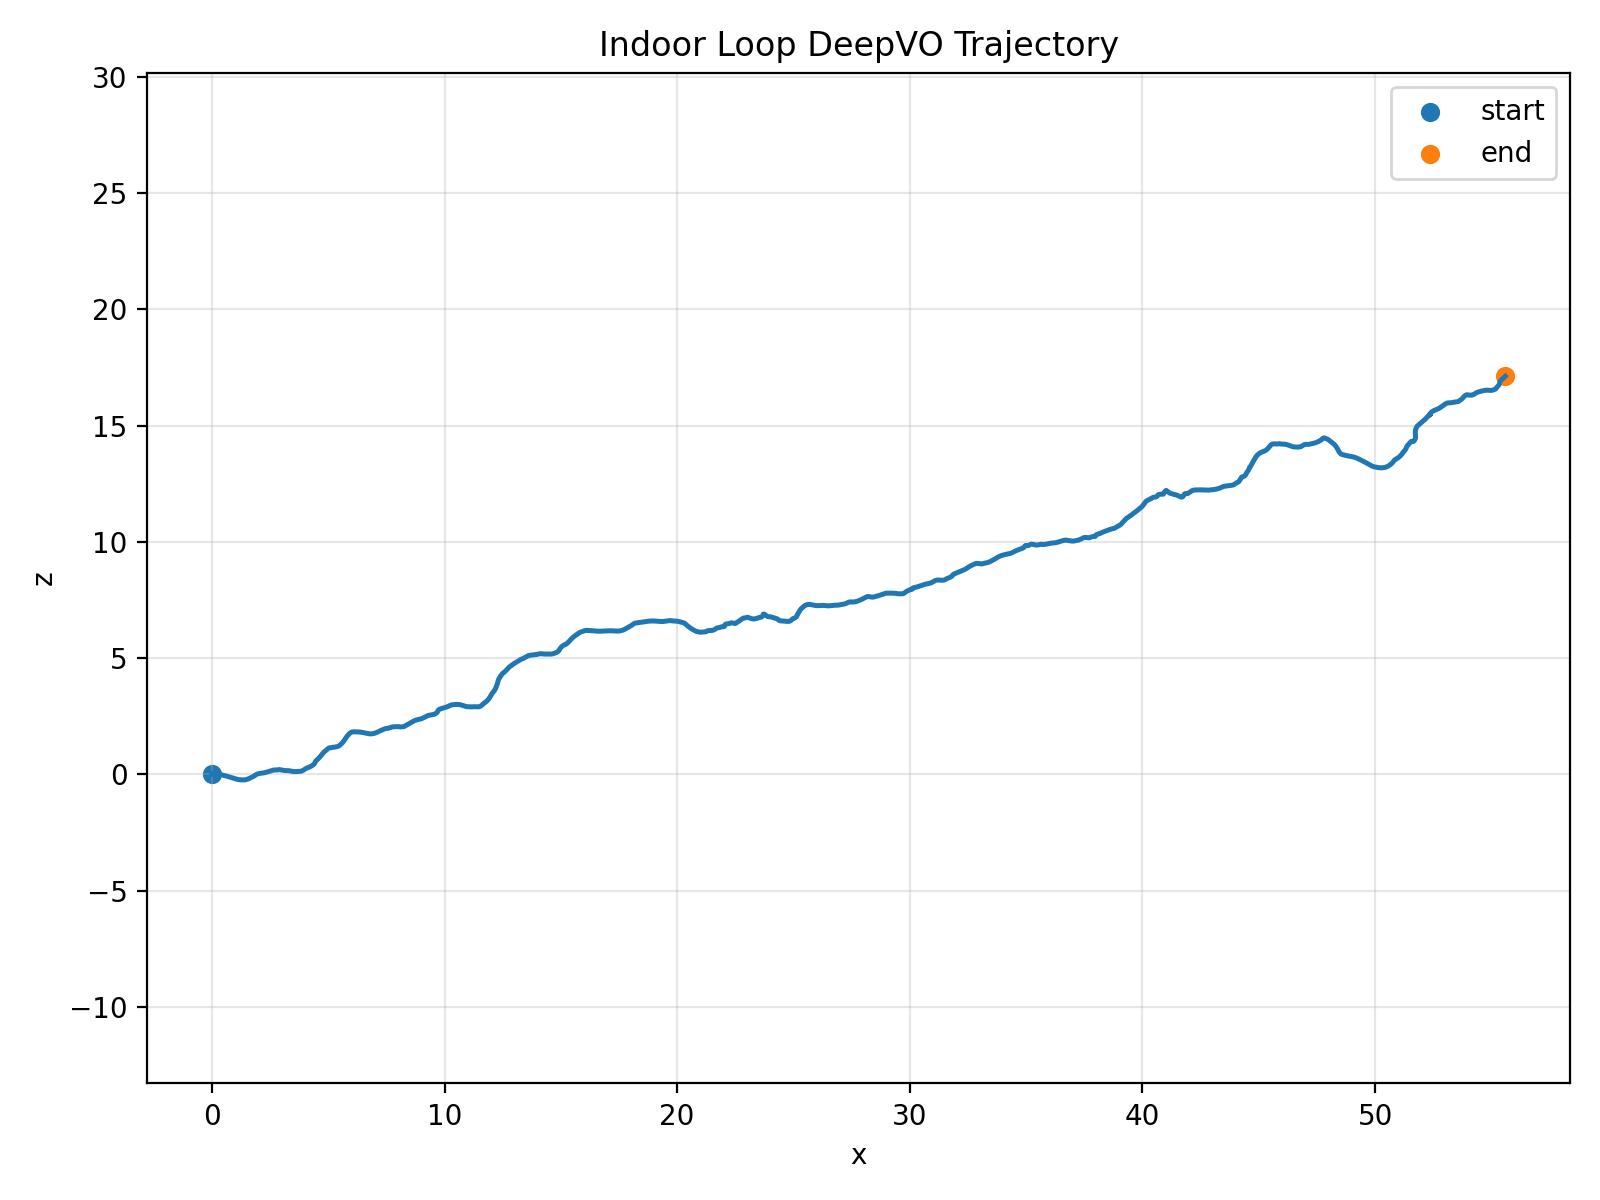

outputs/plots/deepvo/custom_trained/deepvo_custom_trained_indoor_loop_trajectory.png


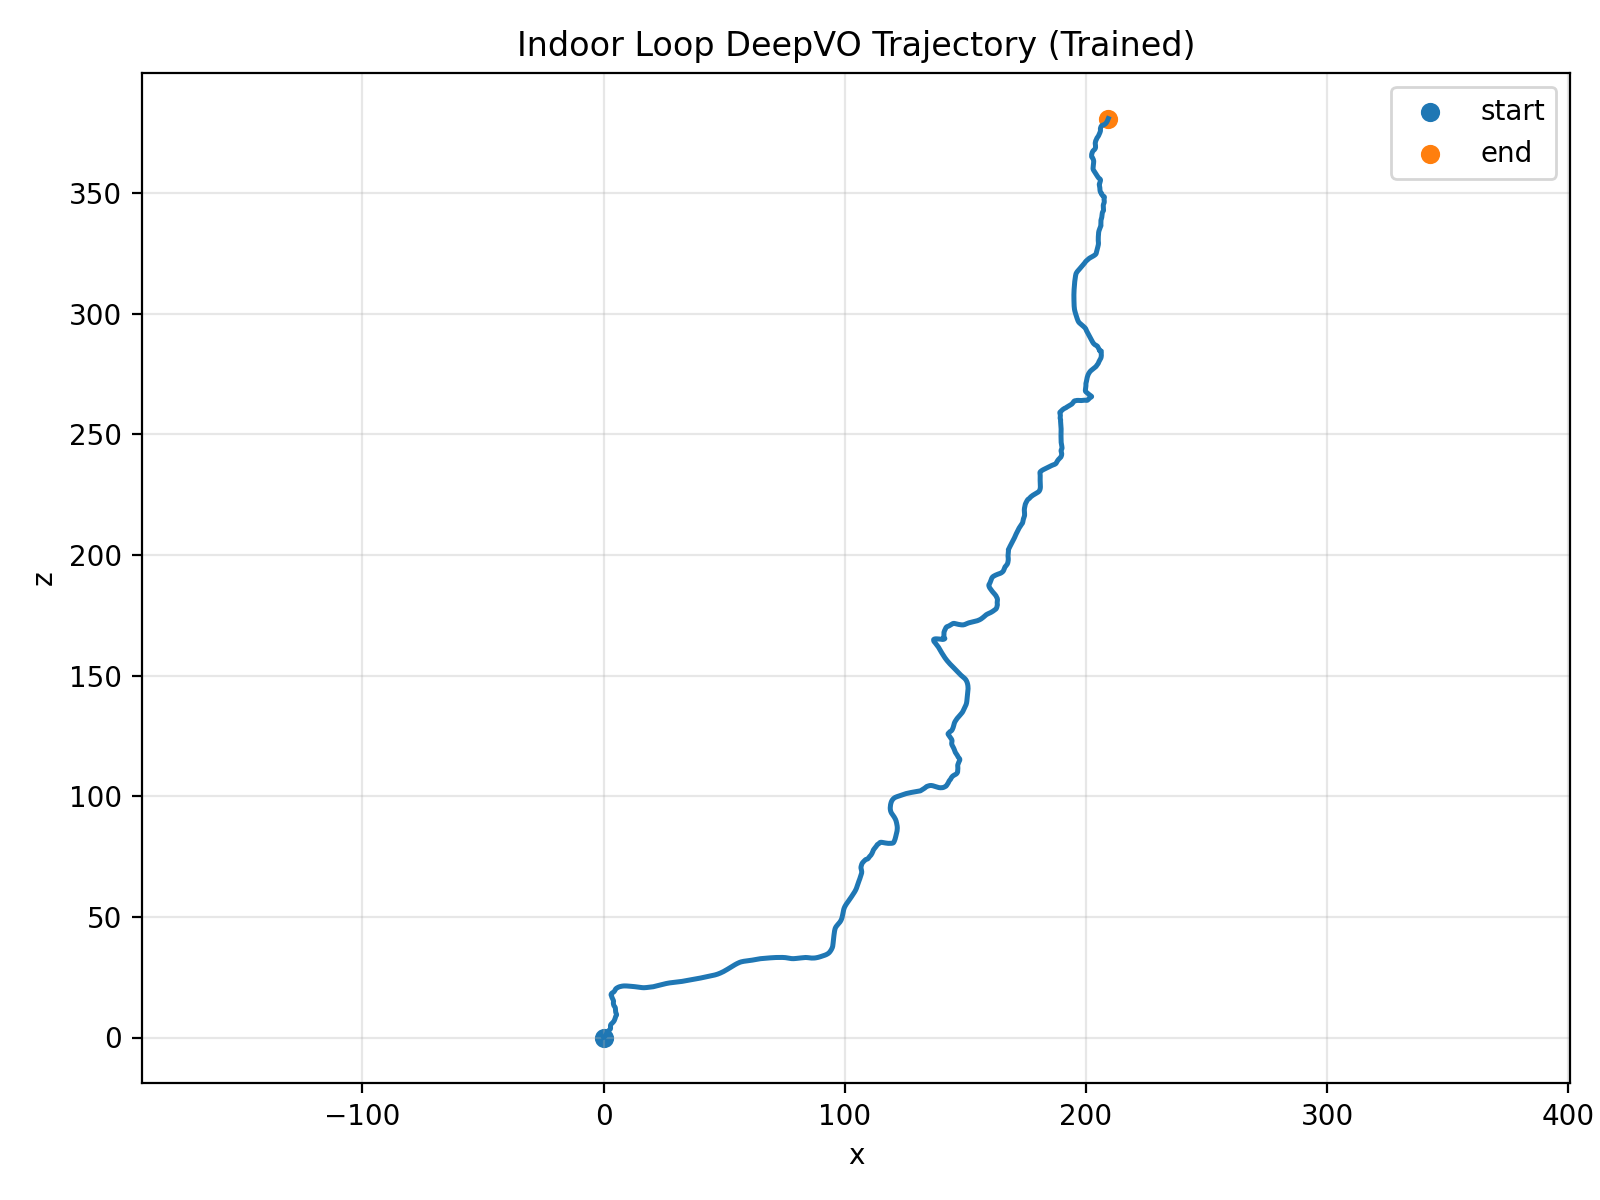

outputs/plots/deepvo/custom_random/deepvo_custom_random_outdoor_loop_trajectory.png


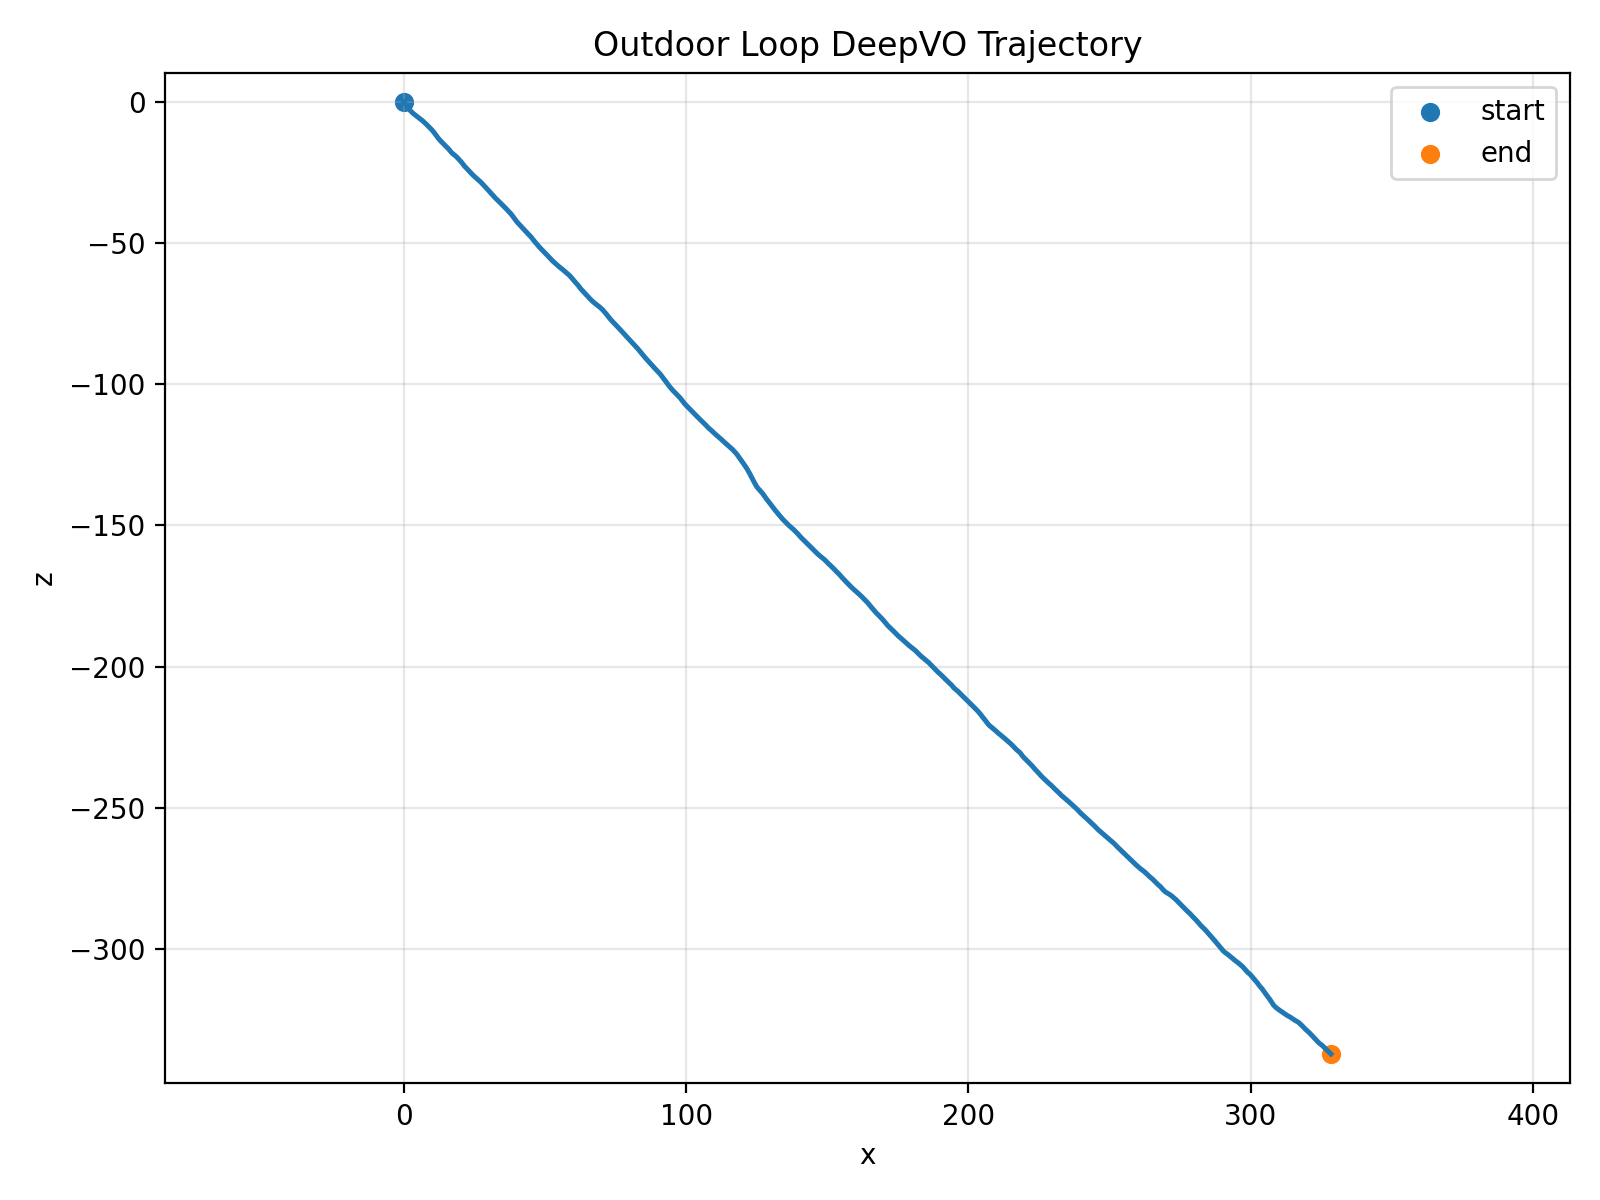

outputs/plots/deepvo/custom_trained/deepvo_custom_trained_outdoor_loop_trajectory.png


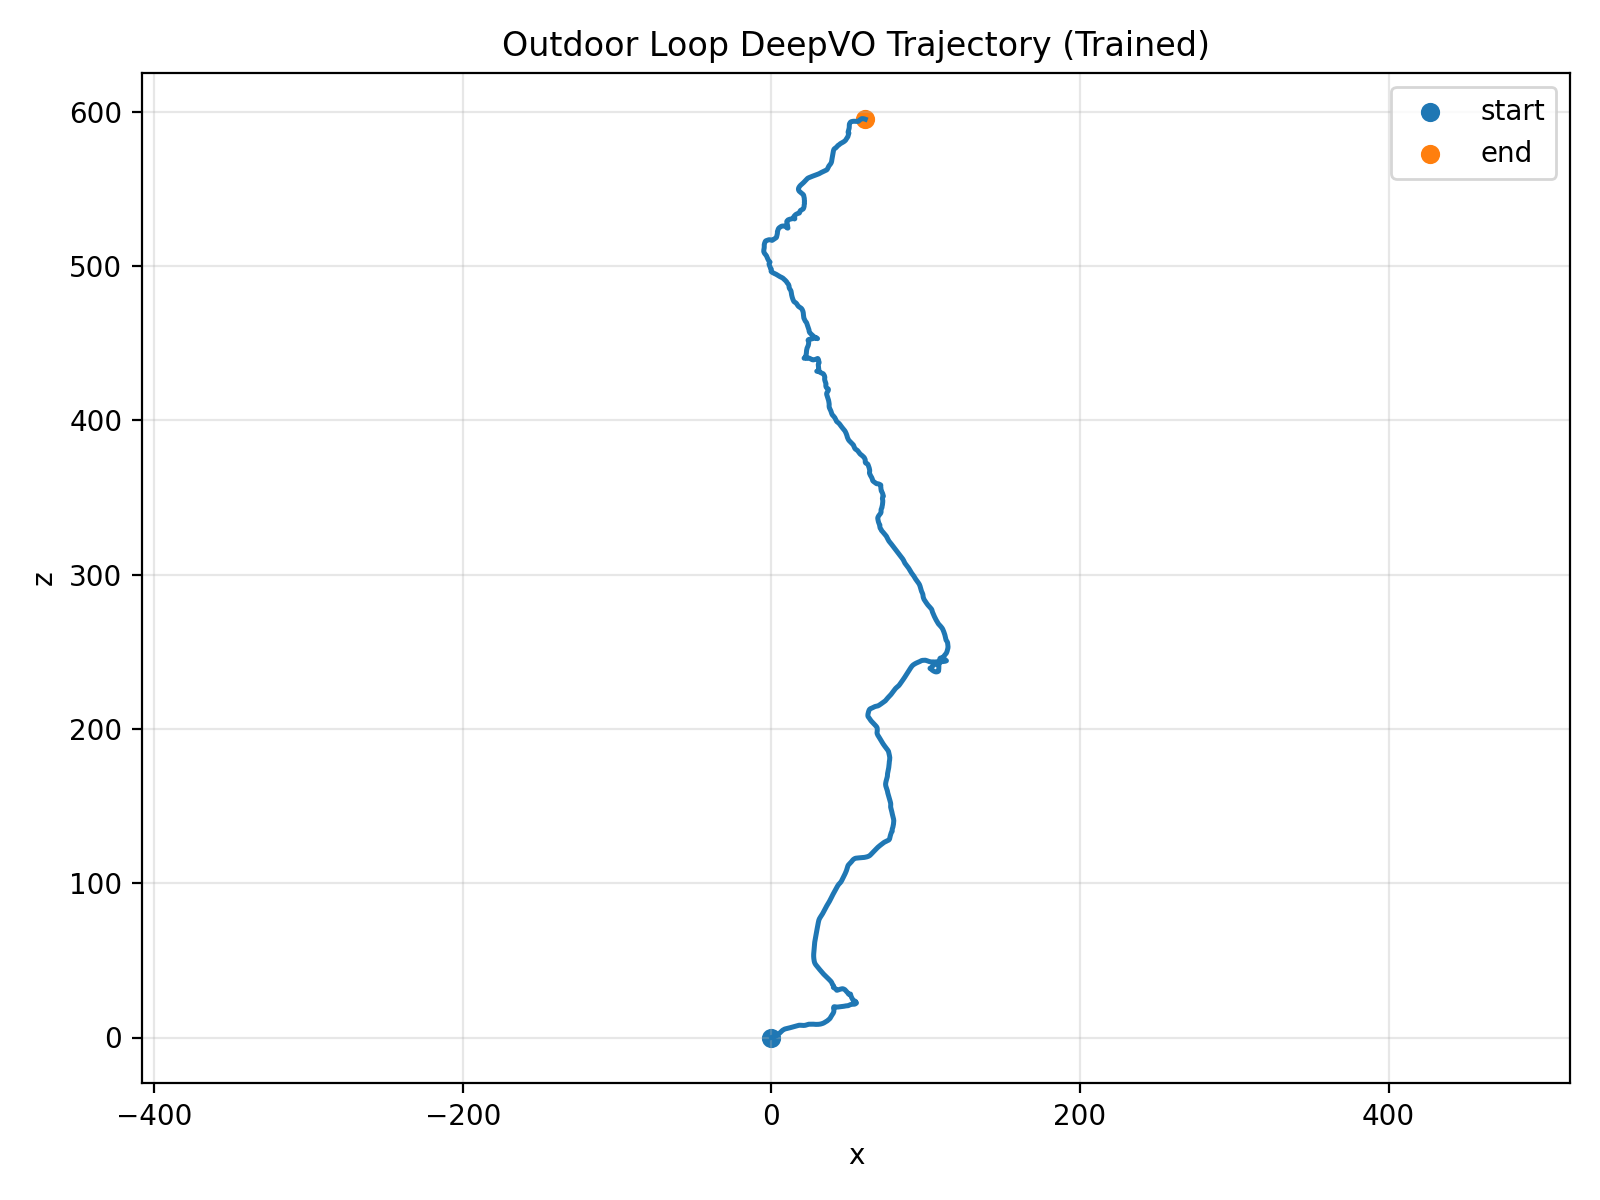

outputs/plots/deepvo/kitti_benchmark/deepvo_kitti_04_trajectory.png


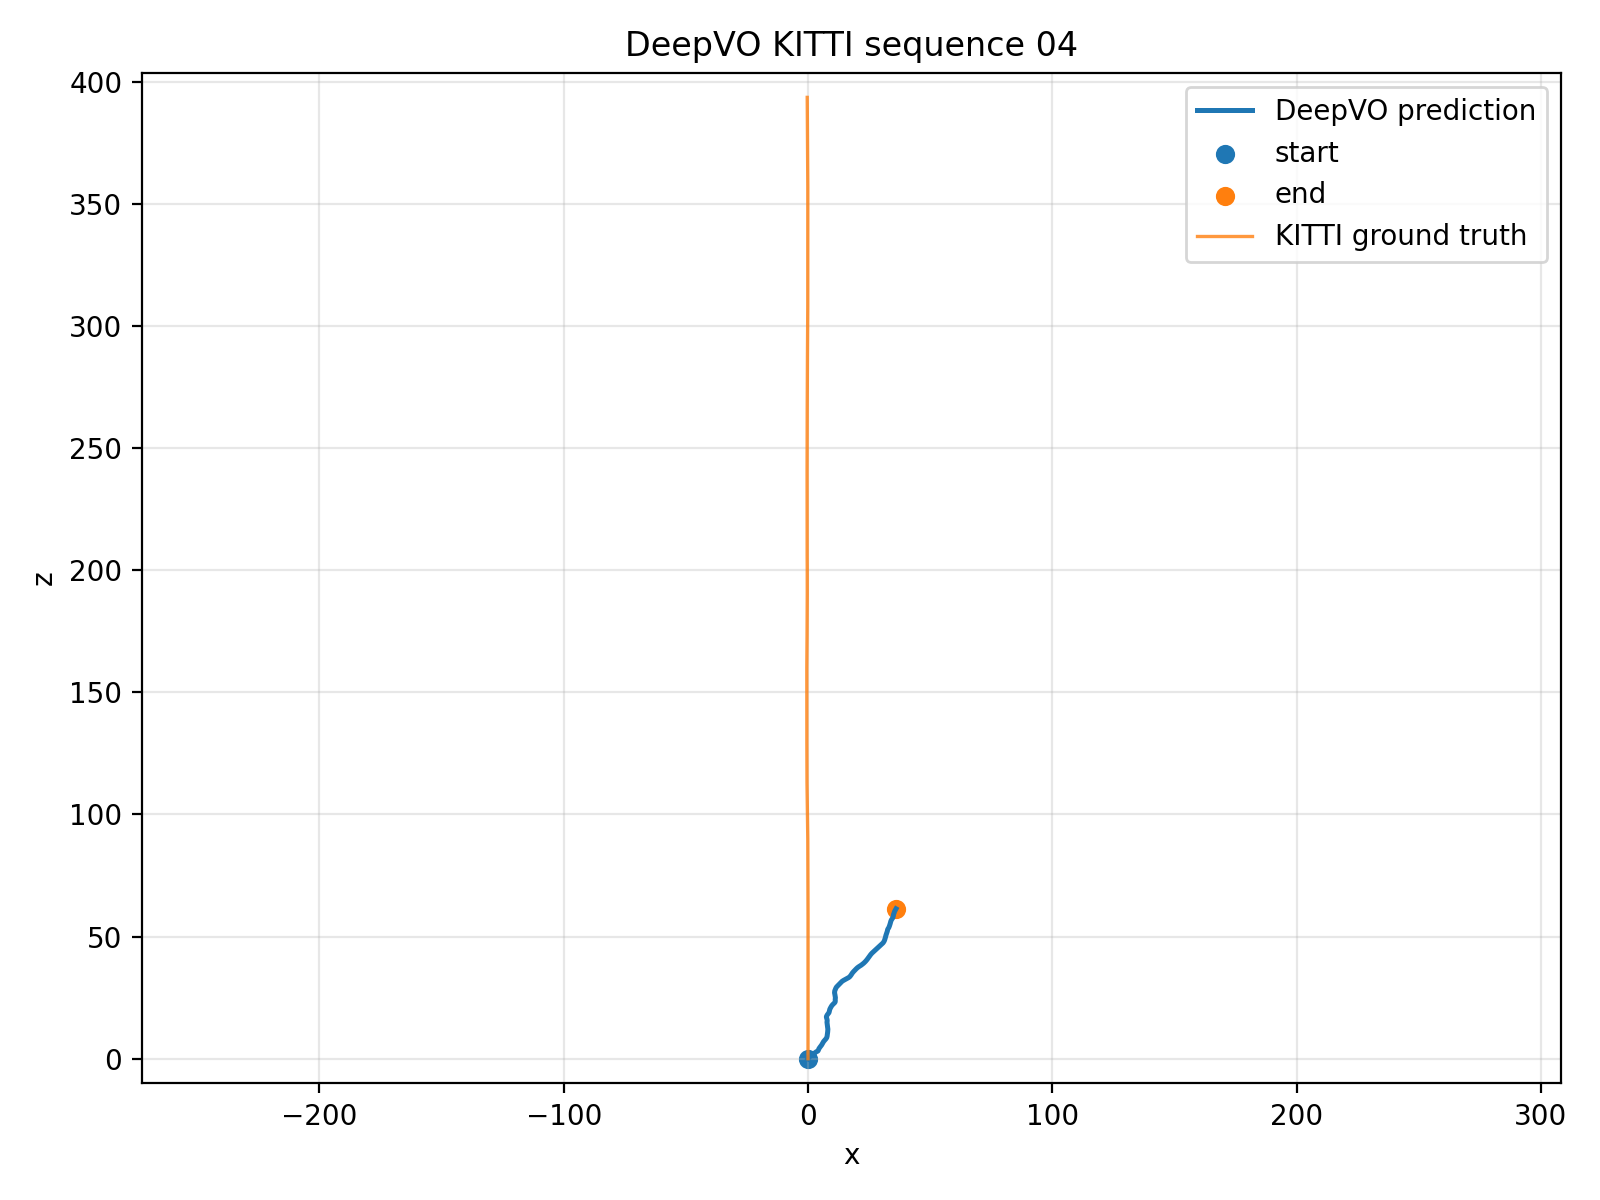

In [11]:
from IPython.display import Image, display

plot_paths = [
    PROJECT_ROOT / "outputs/plots/deepvo/custom_random/deepvo_custom_random_indoor_loop_trajectory.png",
    PROJECT_ROOT / "outputs/plots/deepvo/custom_trained/deepvo_custom_trained_indoor_loop_trajectory.png",
    PROJECT_ROOT / "outputs/plots/deepvo/custom_random/deepvo_custom_random_outdoor_loop_trajectory.png",
    PROJECT_ROOT / "outputs/plots/deepvo/custom_trained/deepvo_custom_trained_outdoor_loop_trajectory.png",
    PROJECT_ROOT / "outputs/plots/deepvo/kitti_benchmark/deepvo_kitti_04_trajectory.png",
]

for plot_path in plot_paths:
    print(plot_path.relative_to(PROJECT_ROOT))
    if plot_path.exists():
        display(Image(filename=str(plot_path), width=650))
    else:
        print("  Missing plot")

## 8. Benchmark Inference on KITTI

KITTI benchmark inference uses `image_0` frames and the trained checkpoint. Outputs are stored under:

- `outputs/trajectories/deepvo/kitti_benchmark/04/`
- `outputs/trajectories/deepvo/kitti_benchmark/06/`

Example command for sequence `04`:

```bash
PYTORCH_ENABLE_MPS_FALLBACK=1 python scripts/inference/run_deepvo_kitti.py \
  --kitti-root data/benchmark/kitti \
  --sequence 04 \
  --image-folder image_0 \
  --checkpoint outputs/checkpoints/deepvo_kitti/checkpoint_1.pth \
  --output-root outputs/trajectories/deepvo/kitti_benchmark \
  --plot-root outputs/plots/deepvo/kitti_benchmark
```

In [7]:
import pandas as pd

kitti_sequence = "04"
pred_csv = PROJECT_ROOT / f"outputs/trajectories/deepvo/kitti_benchmark/{kitti_sequence}/predicted_trajectory.csv"
truth_csv = PROJECT_ROOT / f"outputs/trajectories/deepvo/kitti_benchmark/{kitti_sequence}/ground_truth_trajectory.csv"

if pred_csv.exists():
    pred_df = pd.read_csv(pred_csv)
    print("Predicted trajectory rows:", len(pred_df))
    display(pred_df.head())
else:
    print("Missing predicted trajectory:", pred_csv.relative_to(PROJECT_ROOT))

if truth_csv.exists():
    truth_df = pd.read_csv(truth_csv)
    print("Ground truth rows:", len(truth_df))
    display(truth_df.head())

Predicted trajectory rows: 271


,frame,x,y,z,rx,ry,rz
0,000000.png,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,000001.png,0.079450,0.008051,0.089129,-0.035705,-0.016028,-0.025057
2,000002.png,0.189716,0.058121,0.254547,-0.093426,-0.047525,-0.030626
3,000003.png,0.340454,0.122465,0.465320,-0.182217,-0.080388,0.024069
4,000004.png,0.537962,0.203613,0.697635,-0.269305,-0.109124,0.080519


Ground truth rows: 271


,frame,x,y,z,rx,ry,rz
0,000000.png,-5.551115e-17,0.000000,2.220446e-16,3.562503e-10,-1.704638e-10,1.197625e-11
1,000001.png,1.289128e-03,-0.018216,1.310643e+00,-1.325834e-03,-2.089193e-04,9.037965e-04
2,000002.png,4.448326e-04,-0.042033,2.625299e+00,-1.860628e-03,-5.507574e-04,1.647376e-03
3,000003.png,2.037581e-03,-0.063028,3.941730e+00,-5.386843e-04,-7.293855e-04,3.413854e-03
4,000004.png,2.777892e-03,-0.084838,5.261017e+00,-8.164519e-04,-6.404366e-04,3.635881e-03


## 9. Discussion

### Trained vs Random Results

The random-weight outputs are useful for checking that preprocessing, inference, CSV writing, and plotting all work. They should not be interpreted as meaningful odometry results. The trained outputs use `checkpoint_1.pth`, which gives a more realistic demonstration, although this checkpoint was trained for only one epoch and should be treated as an early experimental baseline.

### Drift Behavior

DeepVO predicts relative motion between frames. The trajectory is produced by accumulating these relative predictions, so small errors compound over time. This is why drift is expected, especially on longer sequences or on custom videos that differ from KITTI.

### DeepVO Is Visual Odometry, Not Full SLAM

DeepVO estimates motion from image sequences, but it does not build a persistent map, perform loop closure, or globally correct accumulated drift. For the broader semester project, this makes DeepVO a useful visual odometry baseline before comparing against a fuller SLAM system such as ORB-SLAM3.

## 10. Final Project Update: outdoor_loop2 and Replay Demo

After the initial indoor/outdoor experiments, a third custom sequence, `outdoor_loop2`, was added to the project. The video was large and portrait-oriented, so frames were extracted with `--max-width 1280` to keep storage practical while preserving the image order.

DeepVO trained-checkpoint inference was run on `outdoor_loop2` and saved results under `outputs/trajectories/deepvo/custom_trained/outdoor_loop2/`. A report plot was generated at `outputs/plots/deepvo/custom_trained/deepvo_custom_trained_outdoor_loop2_trajectory.png`.

The DeepVO pseudo-real-time demo is replay-based: it shows extracted frames and reveals the saved trajectory over time. It is useful for presentation, but it is not live model inference.


outputs/plots/deepvo/custom_trained/deepvo_custom_trained_outdoor_loop2_trajectory.png


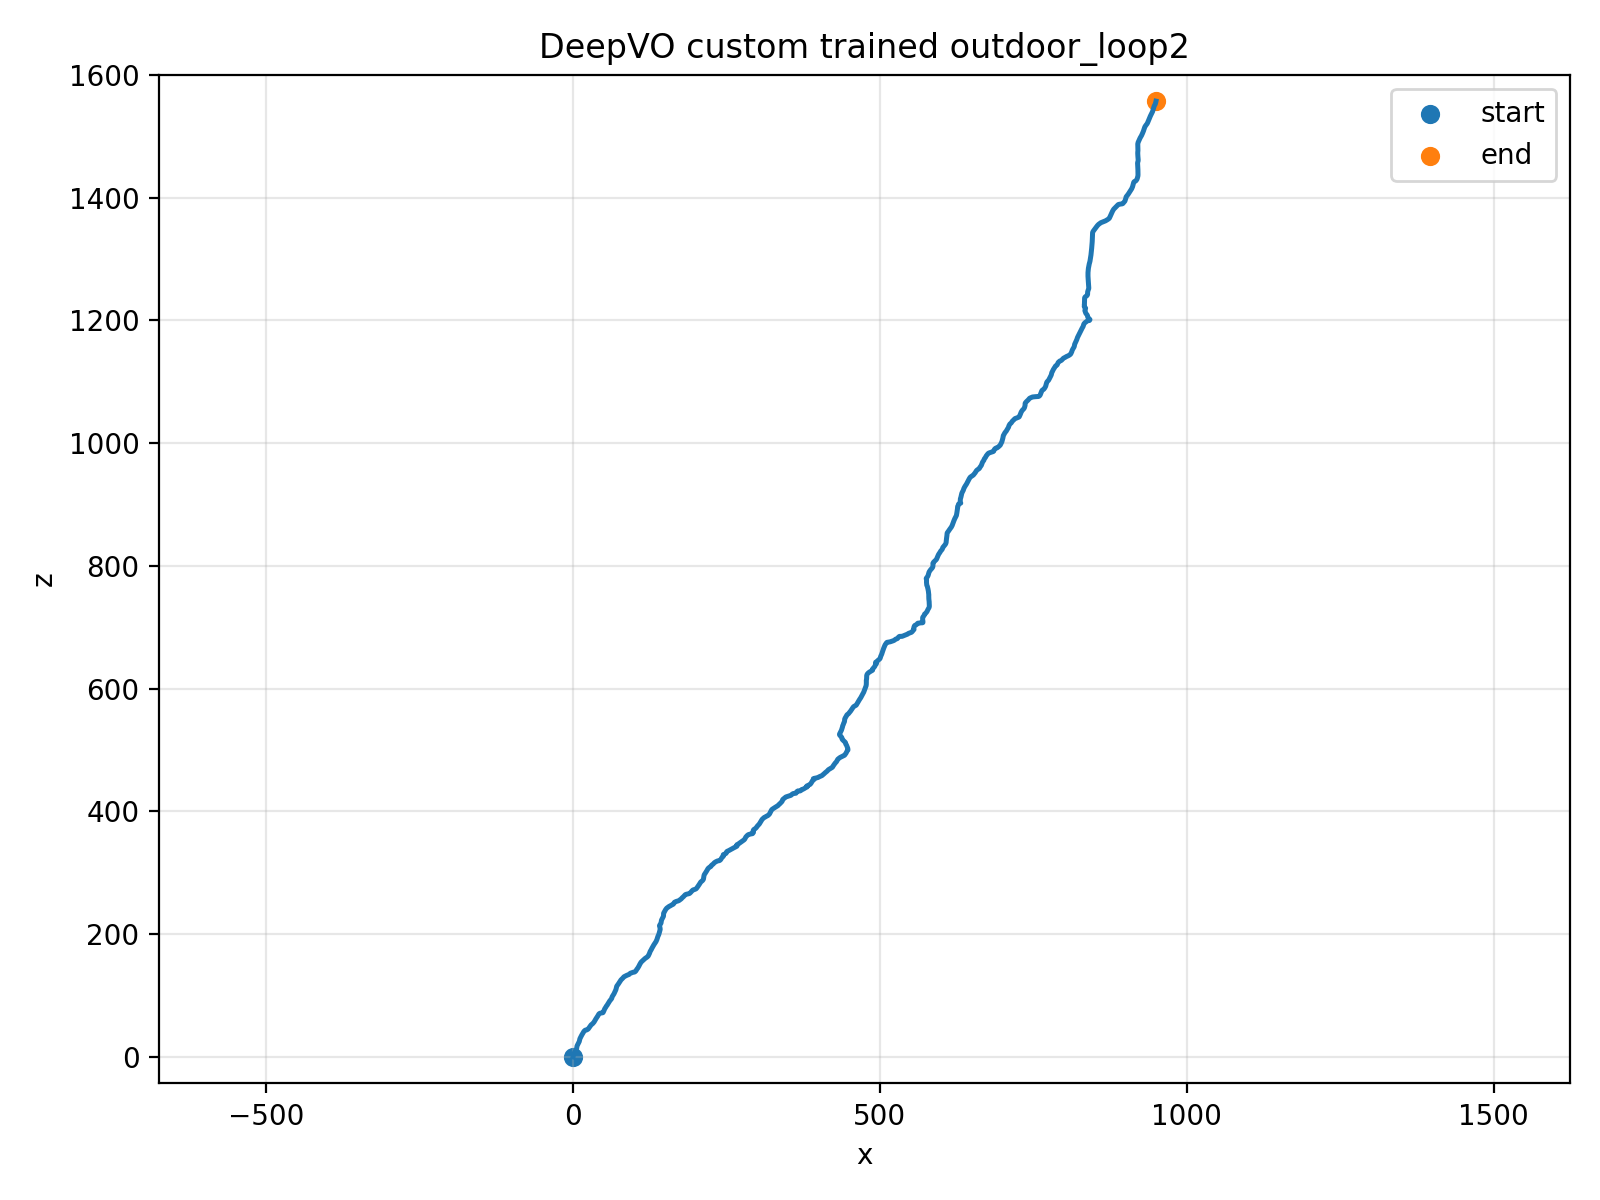

In [12]:
from IPython.display import Image, display

plot_paths = [
    PROJECT_ROOT / "outputs/plots/deepvo/custom_trained/deepvo_custom_trained_outdoor_loop2_trajectory.png",
]

for plot_path in plot_paths:
    print(plot_path.relative_to(PROJECT_ROOT))
    if plot_path.exists():
        display(Image(filename=str(plot_path), width=650))
    else:
        print("  Missing plot")

In [8]:
# DeepVO outdoor_loop2 replay command
!../.venv/bin/python ../scripts/visualization/deepvo_realtime_demo.py \
  --frames ../data/custom/extracted_frames/outdoor_loop2 \
  --trajectory ../outputs/trajectories/deepvo/custom_trained/outdoor_loop2/predicted_trajectory.csv \
  --fps 24


Frames: /Users/ray/monocular-slam-project/monocular_slam_project/data/custom/extracted_frames/outdoor_loop2
Frame count: 5928
Trajectory: /Users/ray/monocular-slam-project/monocular_slam_project/outputs/trajectories/deepvo/custom_trained/outdoor_loop2/predicted_trajectory.csv
Trajectory points: 5928
Press q or Esc in the demo window to quit.
Matplotlib is building the font cache; this may take a moment.
Demo finished.
